#### Instructions
###### Follow the instructions given in comments prefixed with ## and write your code below that.
###### Also fill the partial code in given blanks. 
###### Don't make any changes to the rest part of the codes

### Answer the questions given at the end of this notebook within your report.

### You would need to submit your GitHub repository link. Refer to the PDF document for the instructions and details.





In [3]:
import cv2                          ## import cv2
import numpy as np                 ## import numpy
import matplotlib.pyplot as plt   ## import matplotlib pyplot
from sklearn.cluster import KMeans## import KMeans cluster from sklearn
from scipy.spatial import distance## import distance from scipy.spatial
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

In [4]:
## Reading the image plaksha_Faculty.jpg
img = cv2.imread('plaksha_Faculty.jpg')
  
## Convert the image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  
# Loading the required haar-cascade xml classifier file
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
  
# Applying the face detection method on the grayscale image. 
faces_rect = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)
## Change the parameters for better detection of faces in your case.
faces_rect = face_cascade.detectMultiScale(gray, 1.05, 4, minSize=(25,25), maxSize=(50,50))
 
# Define the text and font parameters
text = f"Faces: {len(faces_rect)}"          
font = cv2.FONT_HERSHEY_SIMPLEX            
font_scale = 1                             
font_color = (0, 0, 255)                   
font_thickness = 2                         

# Draw rectangles around detected faces
for (x, y, w, h) in faces_rect:
    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 0, 255), 2)

# Position the text on the image
text_size = cv2.getTextSize(text, font, font_scale, font_thickness)[0]
text_x = (img.shape[1] - text_size[0] + 400) // 2
text_y = (img.shape[0] // 2 + text_size[1]) // 2

cv2.putText(
    img,
    text,
    (text_x, text_y),
    font,
    font_scale,
    font_color,
    font_thickness,
    cv2.LINE_AA
)

## Display the image and window title should be "Total number of face detected are #"
cv2.imwrite("faculty_faces_detected.jpg", img)
cv2.imshow(f"Total number of face detected are {len(faces_rect)}", img)
cv2.waitKey(0)
cv2.destroyAllWindows()


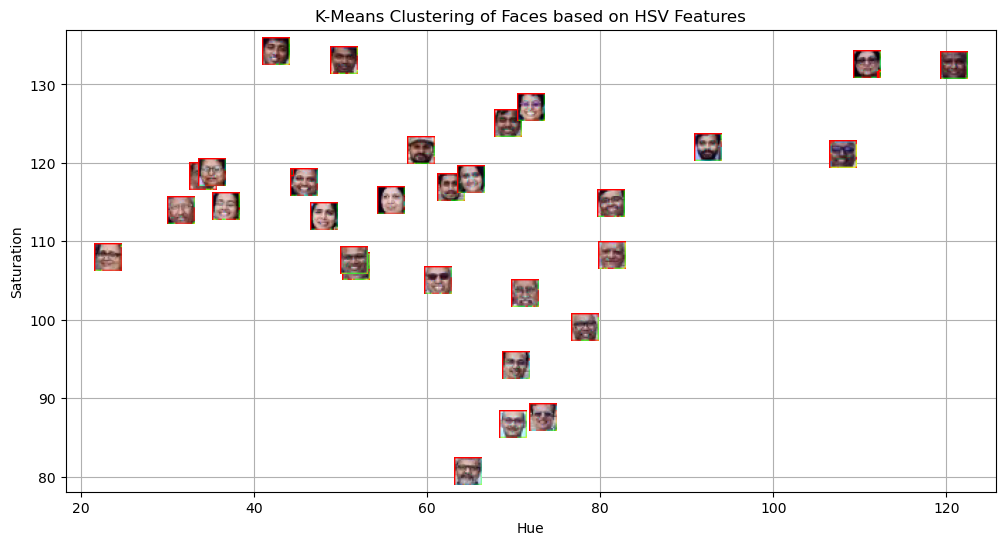

In [5]:

from matplotlib.offsetbox import OffsetImage, AnnotationBbox
# Extract face region features (Hue and Saturation)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV) ## call the img and convert it from BGR to HSV and store in img_hsv
hue_saturation = []
face_images = []  # To store detected face images

for (x, y, w, h) in faces_rect:
    face = img_hsv[y:y + h, x:x + w]
    hue = np.mean(face[:, :, 0])
    saturation = np.mean(face[:, :, 1])
    hue_saturation.append((hue, saturation))
    face_images.append(face)

hue_saturation = np.array(hue_saturation)

## Perform k-Means clustering on hue_saturation and store in kmeans
kmeans = KMeans(n_clusters=2, random_state=0).fit(hue_saturation)
#centroids = kmeans.cluster_centers_
#labels = kmeans.labels_

# Create a figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the clustered faces with custom markers
for i, (x,y,w,h ) in enumerate(faces_rect):
    im = OffsetImage(cv2.cvtColor(cv2.resize(face_images[i], (20, 20)), cv2.COLOR_HSV2RGB))
    ab = AnnotationBbox(im, (hue_saturation[i, 0], hue_saturation[i, 1]), frameon=False, pad=0)
    ax.add_artist(ab)
    plt.plot(hue_saturation[i, 0], hue_saturation[i, 1])
    

## Put x label
## Put y label
## Put title
## Put grid
## show the plot
ax.set_xlabel("Hue")
ax.set_ylabel("Saturation")
ax.set_title("K-Means Clustering of Faces based on HSV Features")
ax.grid(True)

plt.show()

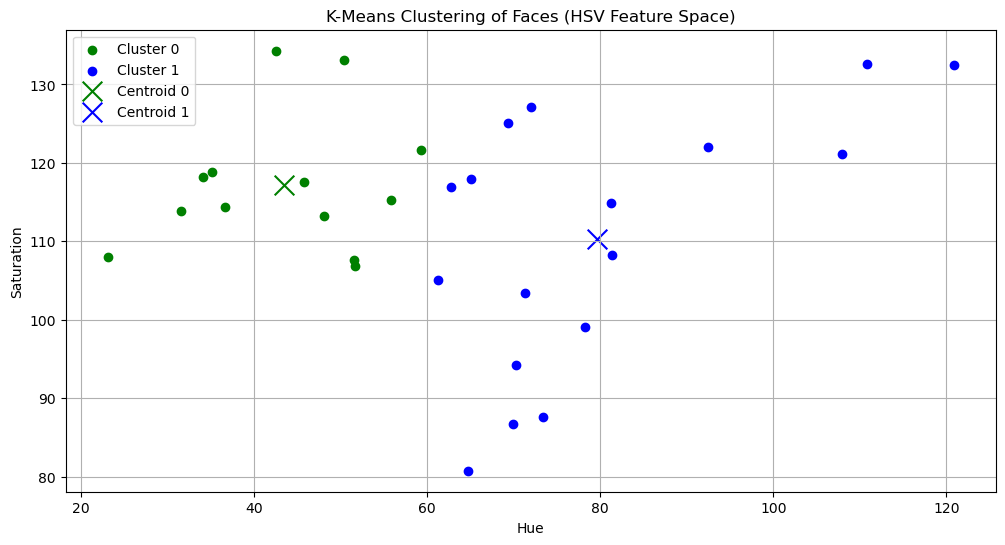

In [6]:
# Create an empty list to store legend labels
legend_labels = []

# Create lists to store points for each cluster
cluster_0_points = []
cluster_1_points = []

# Your code for scatter plot goes here
fig, ax = plt.subplots(figsize=(12, 6))
for i, (x, y, w, h) in enumerate(faces_rect):
    if kmeans.labels_[i] == 0:
        cluster_0_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))
    else:
        cluster_1_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))


cluster_0_points = np.array(cluster_0_points)
# Plot points for cluster 0 in green
plt.scatter(cluster_0_points[:, 0], cluster_0_points[:, 1], color='green', label='Cluster 0')


cluster_1_points = np.array(cluster_1_points)
# Plot points for cluster 1 in blue
plt.scatter(cluster_1_points[:, 0], cluster_1_points[:, 1], color='blue', label='Cluster 1')

# Calculate and plot centroids
centroid_0 = kmeans.cluster_centers_[0]
centroid_1 = kmeans.cluster_centers_[1]

# Plot both the centroid for cluster 0 and cluster 1 
plt.scatter(centroid_0[0], centroid_0[1], color='green', marker='x', s=200, label='Centroid 0')
plt.scatter(centroid_1[0], centroid_1[1], color='blue', marker='x', s=200, label='Centroid 1')

## Put x label
## Put y label
## Put title
## Add a legend
## Add grid
## Show the plot
plt.xlabel("Hue")
plt.ylabel("Saturation")
plt.title("K-Means Clustering of Faces (HSV Feature Space)")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
## Read the class of the template image 'Dr_Shashi_Tharoor.jpg' using cv2 and store it in template_img
template_img = cv2.imread('Dr_Shashi_Tharoor.jpg')
# Detect face  in the template image after converting it to gray and store it in template_faces
template_gray = cv2.cvtColor(template_img, cv2.COLOR_BGR2GRAY)
template_faces = face_cascade.detectMultiScale(template_gray, scaleFactor=1.3, minNeighbors=5)
# Draw rectangles around the detected faces
for (x, y, w, h) in template_faces:
    cv2.rectangle(template_img, (x, y), (x + w, y + h), (0, 255, 0), 3)
cv2.imwrite("template_face_detected.jpg", template_img)
cv2.imshow("Template Face Detection", template_img)
cv2.waitKey(0)
cv2.destroyAllWindows()      

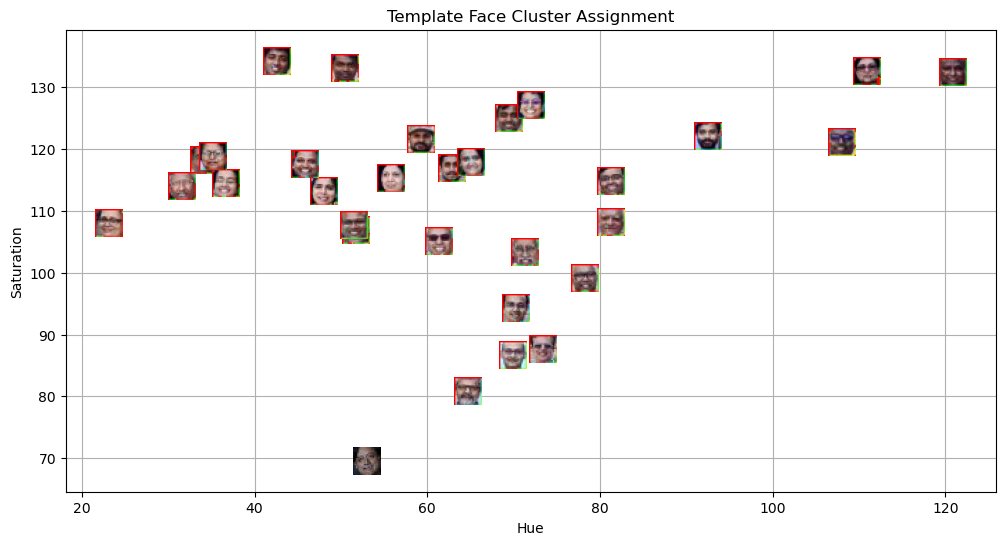

In [8]:
# Convert the template image to HSV color space and store it in template_hsv
template_hsv = cv2.cvtColor(cv2.imread('Dr_Shashi_Tharoor.jpg'), cv2.COLOR_BGR2HSV)

# Extract hue and saturation features from the template image as we did it for detected faces.
for (x, y, w, h) in template_faces:
    template_face = template_hsv[y:y+h, x:x+w]

template_hue = np.mean(template_face[:, :, 0])
template_saturation = np.mean(template_face[:, :, 1])

# Predict the cluster label for the template image and store it in template_label
template_label = kmeans.predict([[template_hue, template_saturation]])[0]

# Create a figure and axis for visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the clustered faces with custom markers (similar to previous code)
for i, (x, y, w, h) in enumerate(faces_rect):
    color = 'red' if kmeans.labels_[i] == 0 else 'blue'
    im = OffsetImage(cv2.cvtColor(cv2.resize(face_images[i], (20, 20)), cv2.COLOR_HSV2RGB))
    ab = AnnotationBbox(im, (hue_saturation[i, 0], hue_saturation[i, 1]), frameon=False, pad=0)
    ax.add_artist(ab)
    plt.plot(hue_saturation[i, 0], hue_saturation[i, 1], 'o', markersize=5, color=color)

# Plot the template image in the respective cluster
if template_label == 0:
    color = 'red'
else:
    color = 'blue'

im = OffsetImage(
    cv2.cvtColor(cv2.resize(template_face, (20, 20)), cv2.COLOR_HSV2RGB)
)

ab = AnnotationBbox(
    im,
    (template_hue, template_saturation),
    frameon=False,
    pad=0
)

ax.add_artist(ab)

## Put x label
## Put y label
## Put title
## Add grid
## show plot
ax.set_xlabel("Hue")
ax.set_ylabel("Saturation")
ax.set_title("Template Face Cluster Assignment")
ax.grid(True)
ax.set_xlim(min(hue_saturation[:,0].min(), template_hue) - 5,
            max(hue_saturation[:,0].max(), template_hue) + 5)

ax.set_ylim(min(hue_saturation[:,1].min(), template_saturation) - 5,
            max(hue_saturation[:,1].max(), template_saturation) + 5)
plt.show()


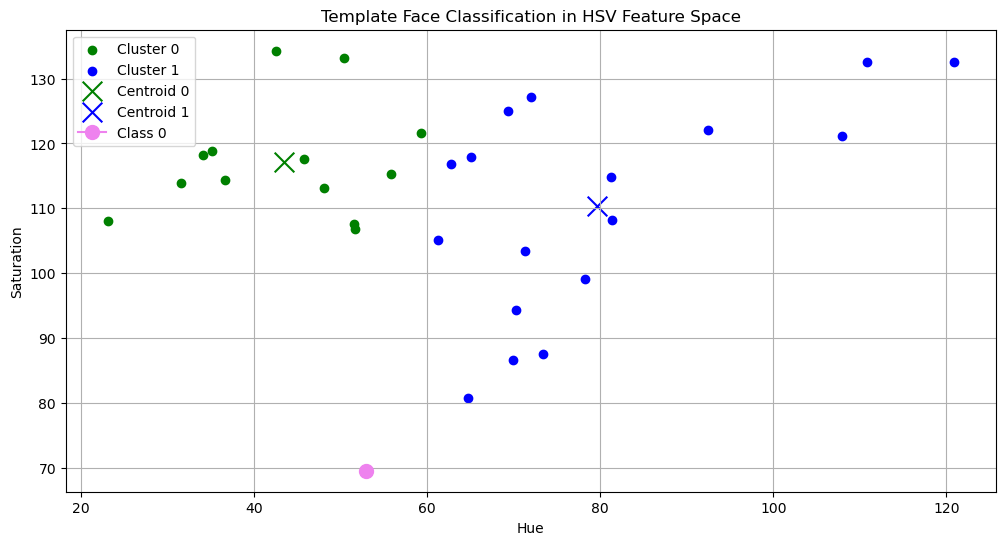

In [9]:
# Create an empty list to store legend labels
legend_labels = []

# Create lists to store points for each cluster
cluster_0_points = []
cluster_1_points = []

# Your code for scatter plot goes here
fig, ax = plt.subplots(figsize=(12, 6))
for i, (x, y, w, h) in enumerate(faces_rect):
    if kmeans.labels_[i] == 0:
        cluster_0_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))
    else:
        cluster_1_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))

# Plot points for cluster 0 in green
cluster_0_points = np.array(cluster_0_points)
plt.scatter(cluster_0_points[:, 0], cluster_0_points[:, 1],color='green', label='Cluster 0')

# Plot points for cluster 1 in blue
cluster_1_points = np.array(cluster_1_points)
plt.scatter(cluster_1_points[:, 0], cluster_1_points[:, 1],color='blue', label='Cluster 1')

# Calculate and plot centroids for both the clusters
centroid_0 = kmeans.cluster_centers_[0]
centroid_1 = kmeans.cluster_centers_[1]
plt.scatter(centroid_0[0], centroid_0[1],marker='x', s=200, color='green', label='Centroid 0') ## plot for centroid 0
plt.scatter(centroid_1[0], centroid_1[1],marker='x', s=200, color='blue', label='Centroid 1')  ## plot for centroid 1
plt.plot(template_hue, template_saturation, marker='o', c= 'violet',markersize= 10, label=f'Class {template_label}' )

## Put x label
## Put y label
## Put title
## Add a legend
## Add grid
## show the plot
plt.xlabel("Hue")
plt.ylabel("Saturation")
plt.title("Template Face Classification in HSV Feature Space")
plt.legend()
plt.grid(True)
plt.show()

                                            ## End of the lab 5 ##

## Report:
## Answer the following questions within your report:


#### 1. What are the common distance metrics used in distance-based classification algorithms? 

#### 2. What are some real-world applications of distance-based classification algorithms? 

#### 3. Explain various distance metrics. 

#### 4. What is the role of cross validation in model performance? 

#### 5. Explain variance and bias in terms of KNN? 